In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Update this path to your file
file_path = "mamajek_stellar_masses.txt"

# Read whitespace-delimited table with header:
# #SpT Teff logT logL Mbol R_Rsun Mv B-V Msun
mamajek_df = pd.read_csv(
    file_path,
    sep=r"\s+",
    engine="python",
    comment=None,   # keep '#SpT' as a header column, not a comment
    skiprows=22
)

# Optional cleanup: remove '#' from the spectral type column name
mamajek_df = mamajek_df.rename(columns={"#SpT": "SpT"})
mamajek_df = mamajek_df[36:80]

mamajek_df.head()

,SpT,Teff,logT,BCv,logL,Mbol,R_Rsun,Mv,B-V,Bt-Vt,...,M_Ks,Ks-W1,W1-W2,W1-W3,W1-W4,g-r,i-z,z-Y,Msun,#SpT.1
36,F0V,7220,3.859,0.01,0.86,2.58,1.728,2.57,0.295,0.317,...,1.836,0.049,-0.026,-0.050,0.003,0.100,...,...,1.61,F0V
37,F1V,7020,3.846,0.005,0.79,2.77,1.679,2.76,0.330,0.350,...,1.941,0.050,-0.026,-0.047,0.009,0.140,...,...,1.50,F1V
38,F2V,6820,3.834,-0.005,0.71,2.97,1.622,2.97,0.370,0.390,...,2.045,0.051,-0.027,-0.046,0.011,0.190,...,...,1.46,F2V
39,F3V,6750,3.829,-0.01,0.67,3.07,1.578,3.08,0.390,0.405,...,2.116,0.051,-0.028,-0.046,0.008,0.210,...,...,1.44,F3V
40,F4V,6670,3.824,-0.015,0.62,3.19,1.533,3.20,0.410,0.428,...,2.188,0.052,-0.029,-0.046,0.000,0.240,...,...,1.38,F4V


      SpT  Teff   Msun    lbol_watts          lxuv        tsat   lxuv_to_sat
36    F0V  7220  1.610  2.773141e+27  6.911288e+23   62.111801  4.292725e+25
37    F1V  7020  1.500  2.360326e+27  6.094335e+23   66.666667  4.062890e+25
38    F2V  6820  1.460  1.963233e+27  5.138017e+23   68.493151  3.519189e+25
39    F3V  6750  1.440  1.790490e+27  4.718356e+23   69.444444  3.276636e+25
40    F4V  6670  1.380  1.595776e+27  4.295685e+23   72.463768  3.112815e+25
41    F5V  6550  1.330  1.389863e+27  3.811063e+23   75.187970  2.865461e+25
42    F6V  6350  1.250  1.030320e+27  2.914184e+23   80.000000  2.331347e+25
43    F7V  6280  1.210  9.396626e+26  2.701340e+23   82.644628  2.232512e+25
44    F8V  6180  1.180  7.464005e+26  2.172856e+23   84.745763  1.841403e+25
45    F9V  6050  1.130  6.352899e+26  1.889873e+23   88.495575  1.672454e+25
46  F9.5V  5990  1.080  5.793912e+26  1.763031e+23   92.592593  1.632436e+25
47    G0V  5930  1.060  5.163830e+26  1.586058e+23   94.339623  1.496281e+25

Text(0, 0.5, 'Lxuv * tsat (joules)')

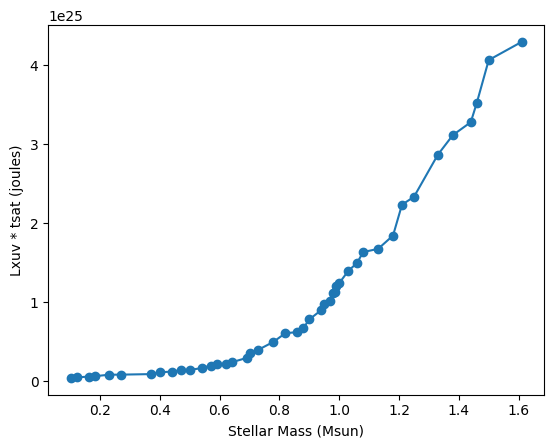

In [53]:
lxuv_lbol_sat = 10**(-3.5)

# Coerce mixed-type columns to numeric (footer/text rows become NaN)
mamajek_df['logL'] = pd.to_numeric(mamajek_df['logL'], errors='coerce')
mamajek_df['Msun'] = pd.to_numeric(mamajek_df['Msun'], errors='coerce')

#turn log L into luminosity
mamajek_df['lbol_sun'] = 10**mamajek_df['logL'] #in solar luminosities
mamajek_df['lbol_watts'] = mamajek_df['lbol_sun'] * 3.828e26 # convert to watts

# Compute Lxuv from logL
mamajek_df['lxuv'] = mamajek_df['lbol_watts']* lxuv_lbol_sat * mamajek_df['Msun'] ** -0.5
mamajek_df['tsat'] = (10**2) * mamajek_df['Msun']**(-1.0) # Myr

mamajek_df['lxuv_to_sat'] = mamajek_df['lxuv'] * mamajek_df['tsat']

print(mamajek_df[['SpT', 'Teff', 'Msun', 'lbol_watts', 'lxuv',  'tsat', 'lxuv_to_sat']])


plt.plot(mamajek_df['Msun'], mamajek_df['lxuv_to_sat'], marker='o')
plt.xlabel('Stellar Mass (Msun)')
plt.ylabel('Lxuv * tsat (joules)')
#plt.xlim(.5,2)
#print(mamajek_df['Msun'])
# plt.ylim(-1,20)

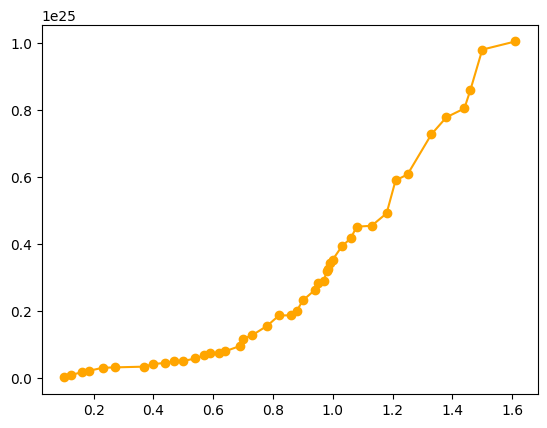

In [63]:
# Estimate stellar age from spectral class (in Gyr)
age_map_gyr = {'M': 1, 'K': 1, 'G': 1, 'F': 1}
mamajek_df['estimated_t_gyr'] = mamajek_df['SpT'].astype(str).str[0].map(age_map_gyr)

# Convert to Myr to match tsat units
mamajek_df['estimated_t_myr'] = mamajek_df['estimated_t_gyr'] * 1e3
# Ratio t / tsat
mamajek_df['estimated_t_over_tsat'] = mamajek_df['estimated_t_myr'] / mamajek_df['tsat']

mamajek_df['luxv_past_sat'] =  mamajek_df['lbol_watts']* lxuv_lbol_sat * mamajek_df['Msun'] ** -0.5 * mamajek_df['estimated_t_over_tsat'] **-1.5

mamajek_df['luxv_past_sat_total'] = mamajek_df['luxv_past_sat'] * (mamajek_df['estimated_t_myr'] - mamajek_df['tsat'])

plt.plot(mamajek_df['Msun'], mamajek_df['luxv_past_sat_total'], marker='o', color='orange')

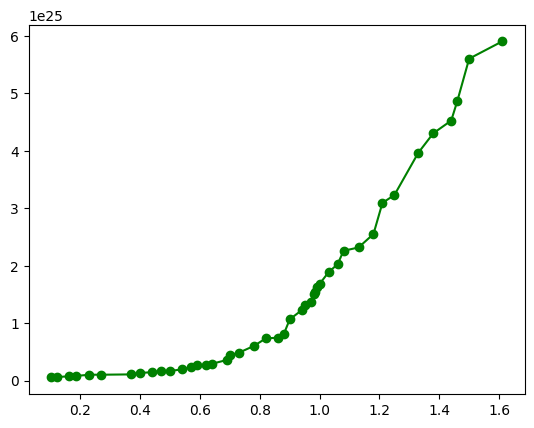

In [62]:
#total lifetime lxuv
mamajek_df['lxuv_full_lifetime'] = mamajek_df['luxv_past_sat_total'] + mamajek_df['lxuv_to_sat']

plt.plot(mamajek_df['Msun'], mamajek_df['lxuv_full_lifetime'], marker='o', color='green')

teff_bin_K  Mstar_med_Msun       a_m  Fxuv_to_sat_J_m2  Fxuv_lifetime_J_m2
 3000-3500       2.500e-01 2.739e+10         2.122e-01           1.070e+02
 3500-4000       5.400e-01 3.614e+10         5.390e-01           1.183e+02
 4000-4500       6.900e-01 4.260e+10         8.821e-01           1.568e+02
 4500-5000       7.550e-01 4.471e+10         1.344e+00           2.160e+02
 5000-5500       8.800e-01 5.627e+10         1.483e+00           2.028e+02
 5500-6000       9.900e-01 5.701e+10         2.911e+00           3.995e+02
 6000-6500       1.195e+00 6.089e+10         5.232e+00           6.056e+02


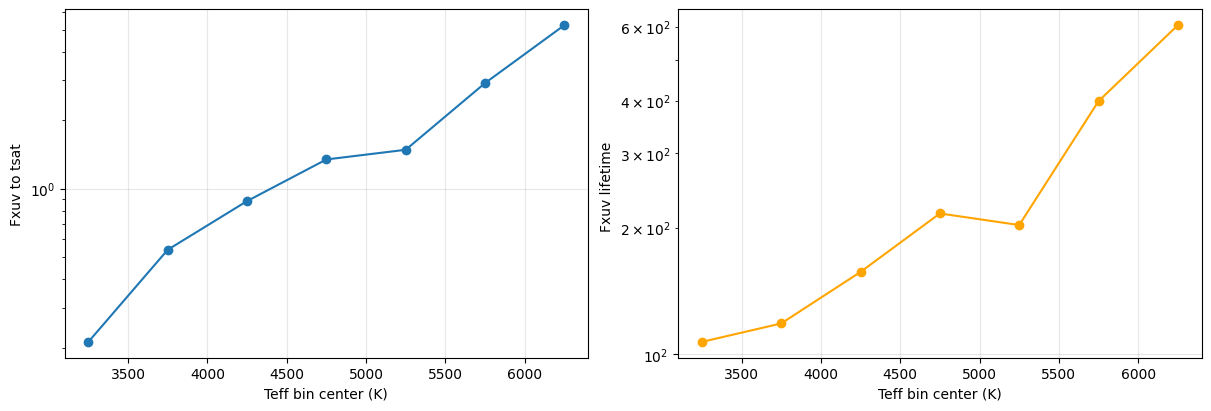

In [75]:
# Simpler Teff-bin incident XUV calculation (no n_planets, no error propagation)
import numpy as np
AU_M = 1.495978707e11  # meters
rows = []
teff_mid = []

teff_bins = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), (5000, 5500), (5500, 6000), (6000, 6500)]
median_period_days = [5.8, 5.98, 6.77, 6.96, 9.10, 8.75, 8.79, 5.80]  # from earlier analysis


teff_num = pd.to_numeric(mamajek_df["Teff"], errors="coerce")

for (tmin, tmax), p_day in zip(teff_bins, median_period_days):
    sub = mamajek_df[(teff_num >= tmin) & (teff_num < tmax)].copy()
    if sub.empty:
        continue

    mstar = pd.to_numeric(sub["Msun"], errors="coerce").median()
    lxuv_to_sat = pd.to_numeric(sub["lxuv"], errors="coerce").median()  # W
    lxuv_life = pd.to_numeric(sub["lxuv_full_lifetime"], errors="coerce").median()  # J

    p_yr = p_day / 365.25
    p_seconds = p_yr * 365.25 * 24 * 3600
    g = 6.67430e-11  # m^3 kg^-1 s^-2
    mstar_kg = mstar * 1.98847e30  # convert Msun to kg

    #newton's version of kepler's third law
    a_m =  ((p_seconds**2) *  (g * mstar_kg) / 4*np.pi**2 )** (1 / 3)

    fxuv_to_sat = lxuv_to_sat / (4 * np.pi * a_m**2)       # J/m^2
    fxuv_life = lxuv_life / (4 * np.pi * a_m**2)     # J/m^2

    rows.append({
        "teff_bin_K": f"{tmin}-{tmax}",
        "Mstar_med_Msun": mstar,
        "a_m": a_m,
        "Fxuv_to_sat_J_m2": fxuv_to_sat,
        "Fxuv_lifetime_J_m2": fxuv_life,
    })
    teff_mid.append((tmin + tmax) / 2)

xuv_incident_df = pd.DataFrame(rows)
print(xuv_incident_df.to_string(index=False, float_format=lambda x: f"{x:.3e}"))

fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

ax[0].plot(teff_mid, xuv_incident_df["Fxuv_to_sat_J_m2"], "o-")
ax[0].set_xlabel("Teff bin center (K)")
ax[0].set_ylabel("Fxuv to tsat")
ax[0].set_yscale("log")
ax[0].grid(alpha=0.3)

ax[1].plot(teff_mid, xuv_incident_df["Fxuv_lifetime_J_m2"], "o-", color="orange")
ax[1].set_xlabel("Teff bin center (K)")
ax[1].set_ylabel("Fxuv lifetime ")
ax[1].set_yscale("log")
ax[1].grid(alpha=0.3)

plt.show()
